In [1]:
!pip install pytransit lightkurve --quiet

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.9/256.9 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.2/309.2 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 734.0/734.0 kB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.8/98.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pytransit import QuadraticModel
import time as t

In [3]:
SEED = 50
np.random.seed(SEED)

N_POINTS = 500
T_HALF = 0.25
time = np.linspace(-T_HALF,T_HALF,N_POINTS)
print(len(time))
print(f"Cadence: {((2*T_HALF)/N_POINTS)*24*60} minutes")

500
Cadence: 1.44 minutes


# Stellar Population Model

In [4]:
# Stellar parameters: T_eff_min, T_eff_max, R_min, R_max, M_min, M_max, u1_min, u1_max, u2_min, u2_max
# Star Types :  M (red dwarf), K (orange), G (sun-like), F (yellow-white), A (white/blue)
# M and K dominate the universe so will have higher probability

star_types = {
    'M': dict(T=(2400,3900), R=(0.1,0.6),  M=(0.08,0.6),  u1=(0.55,0.75), u2=(0.05,0.20), w=0.35),
    'K': dict(T=(3900,5200), R=(0.6,0.9),  M=(0.6,0.9),   u1=(0.45,0.60), u2=(0.10,0.25), w=0.30),
    'G': dict(T=(5200,6000), R=(0.9,1.2),  M=(0.9,1.1),   u1=(0.30,0.50), u2=(0.10,0.25), w=0.20),
    'F': dict(T=(6000,7500), R=(1.2,1.8),  M=(1.1,1.6),   u1=(0.20,0.40), u2=(0.10,0.25), w=0.10),
    'A': dict(T=(7500,10000),R=(1.8,3.0),  M=(1.6,3.0),   u1=(0.10,0.30), u2=(0.05,0.20), w=0.05)
}

star_type_names = list(star_types.keys())
star_type_weights = np.array([star_types[s]['w'] for s in star_type_names])
star_type_weights /= star_type_weights.sum()

print(f"Types: {star_type_names}")
print(f"Weights: {star_type_weights}")

Types: ['M', 'K', 'G', 'F', 'A']
Weights: [0.35 0.3  0.2  0.1  0.05]


In [5]:
def sample_star():
  stype = np.random.choice(star_type_names, p=star_type_weights)
  star = star_types[stype]

  R_star = np.random.uniform(*star['R']) #solar radii
  M_star = np.random.uniform(*star['M']) #solar mass
  T_eff = np.random.uniform(*star['T']) #Kelvin
  u1 = np.random.uniform(*star['u1']) #limb darkening coeff 1
  u2 = np.random.uniform(*star['u2']) #limb darkening coeff 2

  return {
      'R_star': R_star,
      'M_star': M_star,
      'T_eff': T_eff,
      'ldc' : [u1,u2],
      'stype' : stype,
  }

for i in range(5):
  print(f"Star {i+1}: {sample_star()}")

Star 1: {'R_star': 0.6684249313348009, 'M_star': 0.6766421771271633, 'T_eff': 4415.22888263961, 'ldc': [0.5065972646536686, 0.2494861345231974], 'stype': np.str_('K')}
Star 2: {'R_star': 0.8315681984519141, 'M_star': 0.8281610064026653, 'T_eff': 4303.012153290932, 'ldc': [0.5019811806844046, 0.15276472262448437], 'stype': np.str_('K')}
Star 3: {'R_star': 0.5863323423587251, 'M_star': 0.5527727877560948, 'T_eff': 3239.9356555831873, 'ldc': [0.612718149299341, 0.18323000562858327], 'stype': np.str_('M')}
Star 4: {'R_star': 1.0173262342915685, 'M_star': 1.0014368247825953, 'T_eff': 5619.282802131291, 'ldc': [0.48560018556331047, 0.18570596035583897], 'stype': np.str_('G')}
Star 5: {'R_star': 0.9156776073319528, 'M_star': 0.965411460812603, 'T_eff': 5245.121311337195, 'ldc': [0.3359655388127575, 0.2388899758751564], 'stype': np.str_('G')}


# Planet Population Model

In [6]:
AU_IN_RSUN = 215
REARTH_IN_RSUN = 1/109.2

planet_types = {
    'rocky':       dict(R=(0.5,  1.6),  P=(5,   200),  e_max=0.20, w=0.25),
    'super_earth': dict(R=(1.6,  2.5),  P=(5,   200),  e_max=0.15, w=0.25),
    'mini_neptune':dict(R=(2.5,  4.0),  P=(5,   300),  e_max=0.15, w=0.20),
    'neptune':     dict(R=(4.0,  8.0),  P=(10,  500),  e_max=0.20, w=0.15),
    'gas_giant':   dict(R=(8.0,  14.0), P=(10,  1000), e_max=0.30, w=0.10),
    'hot_jupiter': dict(R=(9.0,  15.0), P=(1.5, 10),   e_max=0.05, w=0.05),
}

planet_type_names = list(planet_types.keys())
planet_type_weights = np.array([planet_types[p]['w'] for p in planet_type_names])
planet_type_weights /= planet_type_weights.sum()

def kepler_sma(period,m_star_solar):
  #Kepler's 3rd law: P² ∝ a³/M★
  #a [AU] = (P [years]² × M★ [M☉])^(1/3)
  P_years = period / 365.25
  a_AU = (P_years**2 * m_star_solar)**(1/3)
  return a_AU * AU_IN_RSUN

def sample_planet(star):
  ptype = np.random.choice(planet_type_names, p=planet_type_weights)
  planet = planet_types[ptype]

  R_planet = np.random.uniform(*planet['R'])
  R_planet_RSUN = R_planet * REARTH_IN_RSUN
  period = np.random.uniform(*planet['P'])

  k = R_planet_RSUN / star['R_star']

  a_rsun = kepler_sma(period,star['M_star'])

  z = a_rsun / star['R_star']

  # For a transit to occur: b = (a/R★) cos(i) < 1 + k
  # i > arccos((1+k) * R★/a)
  # We sample uniformly in cos(i) over the valid transiting range

  cos_i_max = (1+k) / max(z, 1.01)
  cos_i_max = min(cos_i_max, 0.999)
  inc_rad = np.arccos(np.random.uniform(0, cos_i_max))

  e = np.random.uniform(0, planet['e_max'])
  w = np.random.uniform(0, 2*np.pi)

  b = z * np.cos(inc_rad)

  return {
        'ptype':          ptype,
        'R_planet_earth': R_planet,
        'k':              k,
        'period':         period,
        'a_over_Rstar':   z,
        'inc_rad':        inc_rad,
        'e':              e,
        'w':              w,
        'b':              b,
        'transit_depth':  k**2,
    }

for i in range(5):
  star = sample_star()
  print(f"Star {i+1}: {star}")
  print(f"Planet {i+1}: {sample_planet(star)}")

Star 1: {'R_star': 1.6284556244604562, 'M_star': 1.4663438044532584, 'T_eff': 6692.621514396648, 'ldc': [0.38626585352118964, 0.16096303650112112], 'stype': np.str_('F')}
Planet 1: {'ptype': np.str_('mini_neptune'), 'R_planet_earth': 3.4748738021335934, 'k': 0.019540715869841477, 'period': 181.63572770552074, 'a_over_Rstar': 94.14888260260814, 'inc_rad': np.float64(1.5683918540849895), 'e': 0.10235357537045682, 'w': 5.516990459387494, 'b': np.float64(0.22637820075222756), 'transit_depth': 0.00038183957670587454}
Star 2: {'R_star': 1.0296006743394244, 'M_star': 1.0835756438316781, 'T_eff': 5825.466942181405, 'ldc': [0.4451500556698543, 0.11872820402343892], 'stype': np.str_('G')}
Planet 2: {'ptype': np.str_('gas_giant'), 'R_planet_earth': 10.326265962381777, 'k': 0.09184422414452699, 'period': 301.98025007175806, 'a_over_Rstar': 188.93609298032575, 'inc_rad': np.float64(1.5672322853882423), 'e': 0.14035386869438535, 'w': 1.6043417149609474, 'b': np.float64(0.6733746330132568), 'transit_

# Transit Physics Engine

In [7]:
_tm = QuadraticModel()
_tm.set_data(time)

def generate_transit(star,planet,t0=0):
  flux = _tm.evaluate(
      k = planet['k'],
      ldc = star['ldc'],
      t0  = t0,
      p   = planet['period'],
      a   = planet['a_over_Rstar'],
      i   = planet['inc_rad'],
      e   = planet['e'],
      w   = planet['w'],
  )

  return np.asarray(flux, dtype=np.float32)


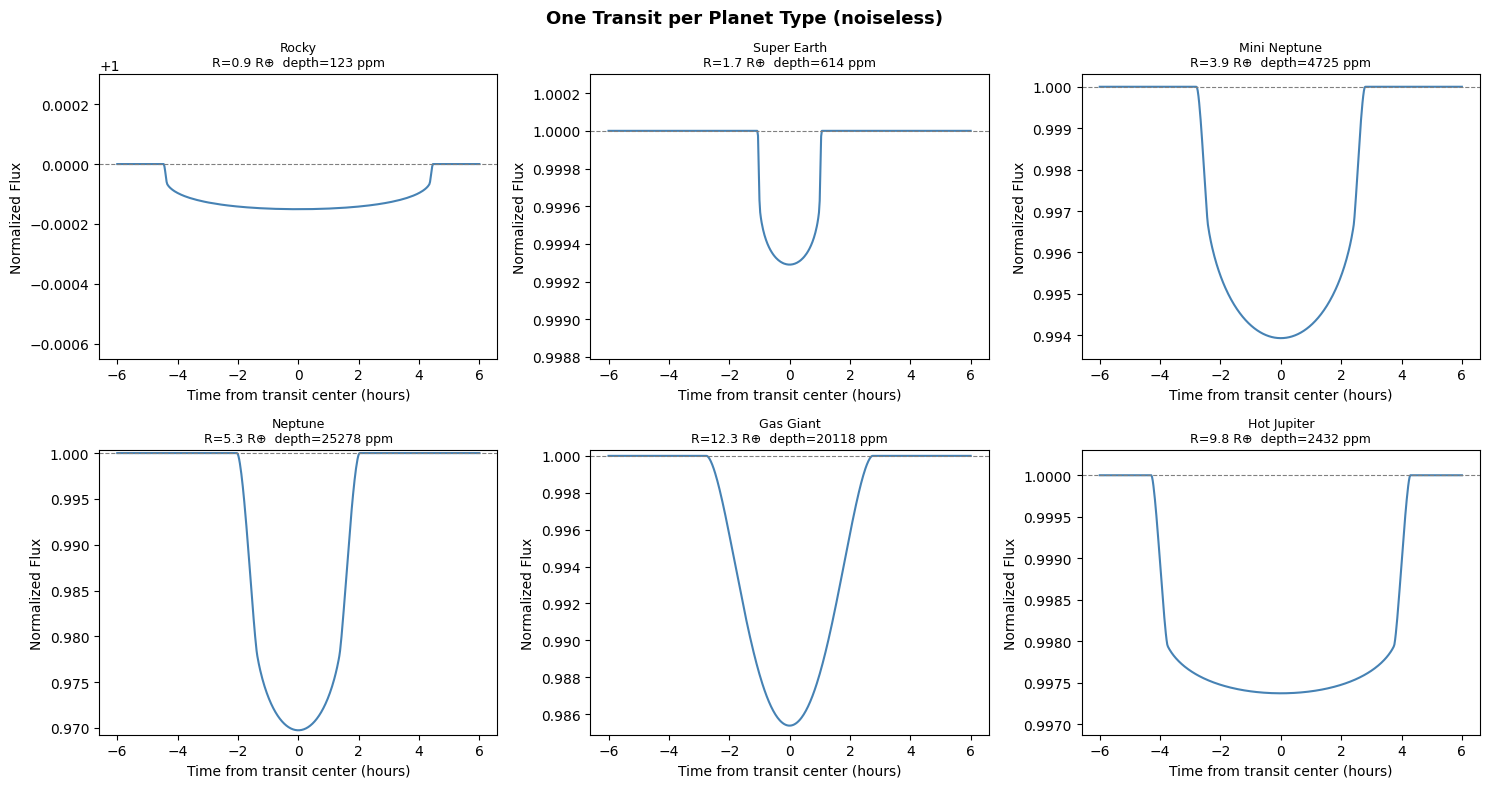


1 ppm = 0.0001% flux drop. Human eye can barely read a chart like this!
Kepler photometry achieves ~30 ppm precision. TESS ~1000 ppm.


In [8]:

# Demo: show one transit per planet type
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, ptype in zip(axes, planet_type_names):
    star   = sample_star()
    planet = sample_planet(star)
    # Force the planet type for demonstration
    planet['ptype'] = ptype
    pdata  = planet_types[ptype]
    planet['R_planet_earth'] = np.random.uniform(*pdata['R'])
    planet['k'] = planet['R_planet_earth'] * REARTH_IN_RSUN / star['R_star']
    planet['transit_depth'] = planet['k']**2

    flux = generate_transit(star, planet)
    depth_ppm = planet['transit_depth'] * 1e6

    ax.plot(time * 24, flux, color='steelblue', lw=1.5)
    ax.axhline(1.0, color='gray', lw=0.8, ls='--')
    ax.set_title(f"{ptype.replace('_',' ').title()}\n"
                 f"R={planet['R_planet_earth']:.1f} R⊕  depth={depth_ppm:.0f} ppm", fontsize=9)
    ax.set_xlabel("Time from transit center (hours)")
    ax.set_ylabel("Normalized Flux")
    ax.set_ylim(min(flux)*0.9995, 1.0003)

plt.suptitle("One Transit per Planet Type (noiseless)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("transit_types.png", dpi=120, bbox_inches='tight')
plt.show()
print("\n1 ppm = 0.0001% flux drop. Human eye can barely read a chart like this!")
print("Kepler photometry achieves ~30 ppm precision. TESS ~1000 ppm.")

# Observational Noise

In [9]:
def add_photon_noise(flux,noise_level=None):
  if noise_level is None:
    noise_level = 10**np.random.uniform(-4.3,-2.8)
  return flux + np.random.normal(0,noise_level,len(flux)),noise_level

def stellar_variability(flux):
  amplitude  = 10 ** np.random.uniform(-4.0, -2.5)
  period_var = np.random.uniform(0.3, 5.0)
  phase      = np.random.uniform(0, 2*np.pi)
  sine_trend = amplitude * np.sin(2*np.pi * time / period_var + phase)

  poly_amp = 10 ** np.random.uniform(-4.5, -3.0)
  degree   = np.random.choice([1, 2])
  t_norm   = time / T_HALF
  poly     = poly_amp * np.polyval(np.random.randn(degree+1)*0.5, t_norm)

  return flux + sine_trend + poly

def dilution(flux,dilution_factor=None):
  if dilution_factor is None:
    dilution_factor = np.random.uniform(0.0, 0.35)
  return (flux - 1.0) * (1.0 - dilution_factor) + 1.0, dilution_factor

def random_gaps(flux,gap_p = 0.03):
  mask = np.random.random(len(flux)) < gap_p
  flux_gapped = flux.copy()
  if mask.any():
      flux_gapped[mask] = np.nan
      nans = np.where(mask)[0]
      valid_idx = np.where(~mask)[0]
      flux_gapped[nans] = np.interp(time[nans], time[valid_idx], flux[valid_idx])
  return flux_gapped

In [10]:
def generate_noisy_transit(clean_flux):
  flux = clean_flux.copy()

  # 1.Dilution
  flux, dil = dilution(flux)
  # 2.Stellar variability
  flux = stellar_variability(flux)
  # 3. Gaps
  flux = random_gaps(flux)
  # 4. Photon noise
  flux, noise = add_photon_noise(flux)
  return flux.astype(np.float32), {'dilution': dil, 'noise_level': noise}

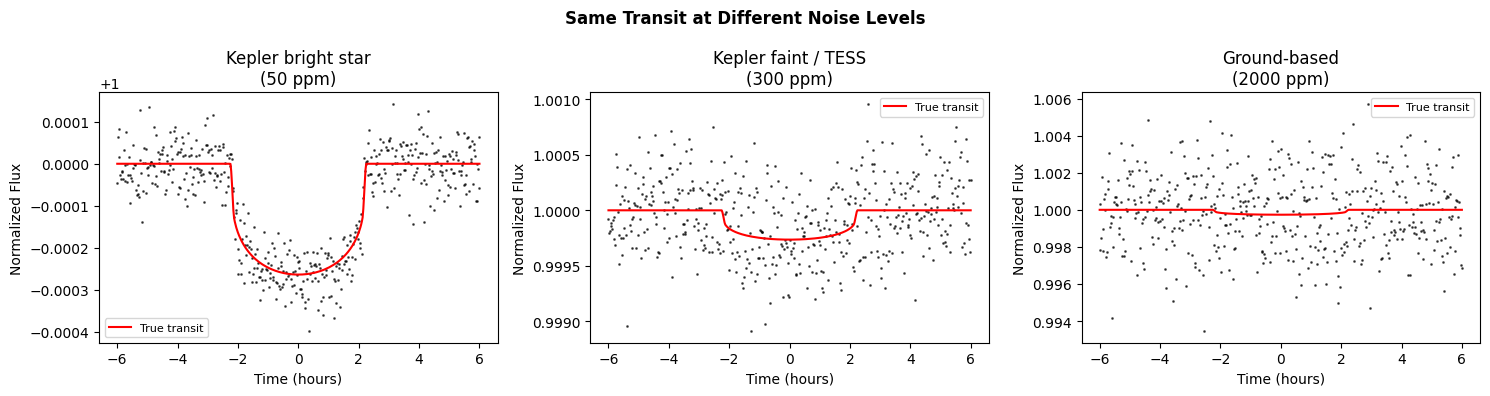

In [11]:
#Demo: Noisy Transit

star = sample_star()
planet = sample_planet(star)
clean_flux = generate_transit(star, planet)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
noise_levels = [5e-5, 3e-4, 2e-3]
labels = ['Kepler bright star\n(50 ppm)', 'Kepler faint / TESS\n(300 ppm)', 'Ground-based\n(2000 ppm)']

for ax, nl, lb in zip(axes, noise_levels, labels):
    f, _ = add_photon_noise(clean_flux, nl)
    ax.plot(time*24, f, 'k.', ms=2, alpha=0.6)
    ax.plot(time*24, clean_flux, 'r-', lw=1.5, label='True transit')
    ax.set_title(lb)
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Normalized Flux")
    ax.legend(fontsize=8)

plt.suptitle("Same Transit at Different Noise Levels", fontweight='bold')
plt.tight_layout()
plt.savefig("noise_demo.png", dpi=120, bbox_inches='tight')
plt.show()

# False Positives

In [12]:
def gen_eclipsing_binary():
  depth_primary = np.random.uniform(0.005,0.15)
  depth_secondary = depth_primary * np.random.uniform(0.1,0.9)
  period          = np.random.uniform(0.5, 10.0)
  duration        = np.random.uniform(0.05, 0.3)
  t0_primary      = np.random.uniform(-T_HALF*0.3, T_HALF*0.3)

  flux = np.ones(len(time))

#Primary eclipse
  for t_center,depth in [(t0_primary,depth_primary)]:
    d2 = duration/2
    ingress = t_center - d2 * 0.3
    flat = t_center - d2 * 0.7
    for i,t in enumerate(time):
      dt = abs(t-t_center)
      if dt < d2 * 0.7:
        flux[i] -= depth
      elif dt < d2 * 0.3:
        frac = (dt - d2*0.7) / (d2 * 0.3)
        flux[i] -= depth * (1 - frac)

#Secondary eclipse if in window
  t_secondary = t0_primary + period/2
  if -T_HALF < t_secondary < T_HALF :
    d2 = duration/2
    for i, t in enumerate(time):
      dt = abs(t - t_secondary)
      if dt < d2 * 0.7:
          flux[i] -= depth_secondary
      elif dt < d2:
          frac = (dt - d2*0.7) / (d2*0.3)
          flux[i] -= depth_secondary * (1 - frac)

  return np.asarray(flux, dtype=np.float32)



def gen_stellar_flare():
  flux = np.ones(len(time))
  n_flares = np.random.randint(1, 4)
  for _ in range(n_flares):
    t_peak = np.random.uniform(-T_HALF*0.8, T_HALF*0.8)
    amp = np.random.uniform(0.001, 0.05)
    tau_rise   = np.random.uniform(0.005, 0.02)
    tau_decay  = np.random.uniform(0.02, 0.1)

    for i, t in enumerate(time):
      dt = t - t_peak
      if dt < 0:
        flux[i] += amp * np.exp(dt/tau_rise)
      else:
        flux[i] += amp * np.exp(-dt/tau_decay)
  return flux.astype(np.float32)


def gen_flat_no_transit():
  return np.ones(len(time),dtype=np.float32)

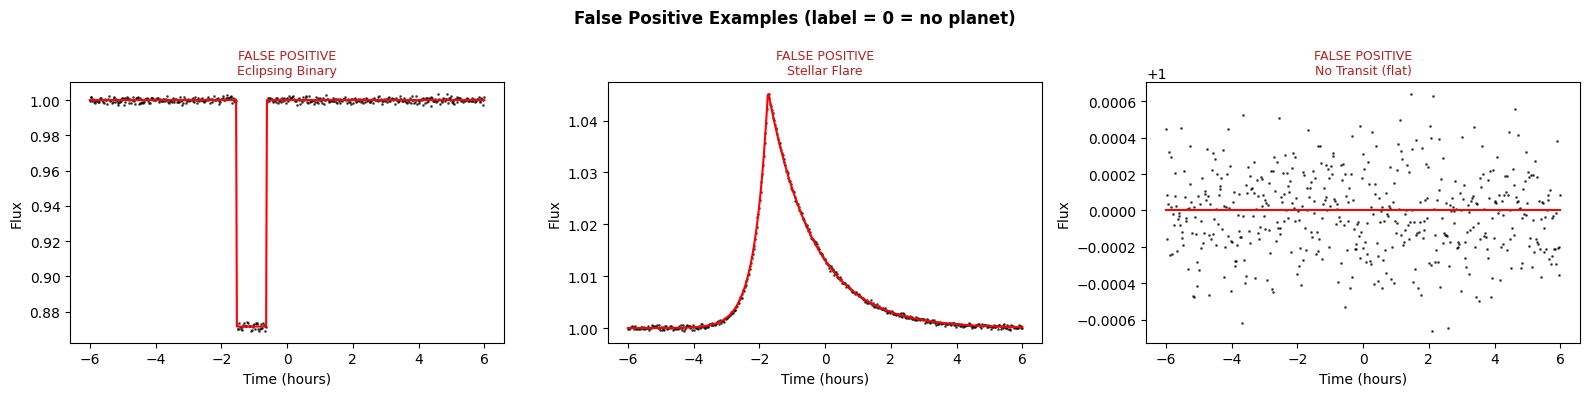

In [13]:
#Demo: False Positives

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fp_generators = [gen_eclipsing_binary, gen_stellar_flare,gen_flat_no_transit]
fp_names = ['Eclipsing Binary', 'Stellar Flare', 'No Transit (flat)']

for ax, gen, name in zip(axes, fp_generators, fp_names):
    flux_clean = gen()
    flux_noisy, _ = add_photon_noise(flux_clean)
    ax.plot(time*24, flux_noisy, 'k.', ms=2, alpha=0.6)
    ax.plot(time*24, flux_clean, 'r-', lw=1.5)
    ax.set_title(f"FALSE POSITIVE\n{name}", color='firebrick', fontsize=9)
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Flux")

plt.suptitle("False Positive Examples (label = 0 = no planet)", fontweight='bold')
plt.tight_layout()
plt.savefig("false_positives.png", dpi=120, bbox_inches='tight')
plt.show()


# Multi Planet System

In [14]:
def gen_multi_planet_flux(star,n_planets=None,label_override=None):
  if n_planets is None:
    n_planets = np.random.choice([1,2,2,3,4], p=[0.45,0.30,0.15,0.07,0.03])

  planets = [sample_planet(star) for _ in range(n_planets)]
  flux_combined = np.ones(N_POINTS,dtype=np.float32)
  transit = False

  for planet in planets:
    t0_offset = np.random.uniform(-T_HALF*0.5, T_HALF*0.5)
    flux_i = generate_transit(star, planet, t0_offset)

    if np.any(flux_i < 0.9999):
      transit = True

    flux_combined *= flux_i

  label = 1 if transit else 0
  if label_override is not None:
    label = label_override

  return flux_combined, label, {'n_planets': n_planets, 'planets': planets}


{'n_planets': 2, 'planets': [{'ptype': np.str_('super_earth'), 'R_planet_earth': 2.44993609080312, 'k': 0.01877644368116474, 'period': 150.90573333425672, 'a_over_Rstar': 100.59644447795804, 'inc_rad': np.float64(1.5606712069439075), 'e': 0.12357274467306201, 'w': 5.290690008331548, 'b': np.float64(1.0185336537002043), 'transit_depth': 0.00035255483731195126}, {'ptype': np.str_('neptune'), 'R_planet_earth': 7.066978170850574, 'k': 0.054161705735555773, 'period': 33.530624419966855, 'a_over_Rstar': 36.903982166784765, 'inc_rad': np.float64(1.5603700666448068), 'e': 0.01189689179196587, 'w': 1.8804729969147007, 'b': np.float64(0.38476354748130187), 'transit_depth': 0.002933490368184935}]}


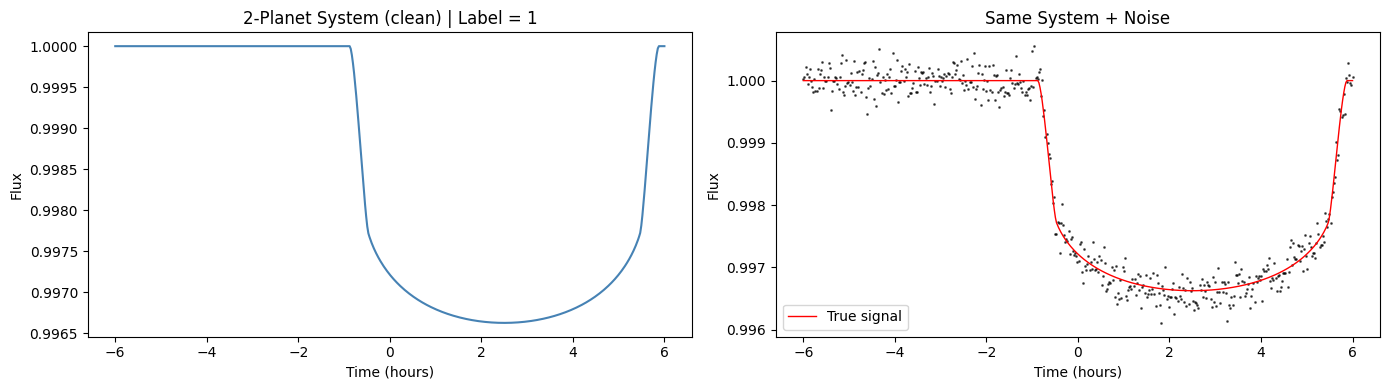

In [15]:
#Demo: Multi Planet System

star = sample_star()
flux_mp, lbl, meta = gen_multi_planet_flux(star, n_planets=2)
print(meta)
flux_noisy, _ = add_photon_noise(flux_mp)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(time*24, flux_mp, 'steelblue', lw=1.5)
ax1.set_title(f"2-Planet System (clean) | Label = {lbl}")
ax2.plot(time*24, flux_noisy, 'k.', ms=2, alpha=0.6)
ax2.plot(time*24, flux_mp, 'r-', lw=1, label='True signal')
ax2.legend()
ax2.set_title("Same System + Noise")
for ax in [ax1, ax2]:
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Flux")
plt.tight_layout()
plt.savefig("multi_planet.png", dpi=120, bbox_inches='tight')
plt.show()

# Dataset Assembly

In [16]:
def generate_dataset(n_total=10000,pos_frac = 0.8,verbose=True):
  n_pos = int(n_total * pos_frac)
  n_neg = n_total - n_pos

  neg_types = ['eclipsing_binary', 'stellar_flare', 'flat_no_transit']
  neg_counts = [int(n_neg * f) for f in [0.35, 0.25, 0.20]]
  neg_counts[-1] = n_neg - sum(neg_counts[:-1])

  X_raw = np.zeros((n_total, N_POINTS), dtype=np.float32)
  y     = np.zeros(n_total, dtype=np.int64)
  meta  = []
  idx = 0
#positives
  for i in range(n_pos):
    star = sample_star()
    if np.random.random() < 0.25:
      flux_clean,lbl,m = gen_multi_planet_flux(star)
    else:
      planet = sample_planet(star)
      t0_offset = np.random.uniform(-T_HALF*0.3, T_HALF*0.3)
      flux_clean = generate_transit(star,planet,t0_offset)
      lbl = 1
      m   = {'type': planet['ptype'], 'stype': star['stype']}
    flux_obs,noise_m = generate_noisy_transit(flux_clean)

    X_raw[idx] = flux_obs
    y[idx] = lbl
    meta.append({'label': lbl, 'class': 'planet', **m, **noise_m})
    idx += 1

    if verbose and (i+1) % 500 == 0:
      print(f"  Positives: {i+1}/{n_pos}")

#negatives
  neg_generators = {
        'eclipsing_binary': gen_eclipsing_binary,
        'stellar_flare':    gen_stellar_flare,
        'flat_no_transit':  gen_flat_no_transit,
    }

  for neg_type,count in zip(neg_types,neg_counts):
    gen = neg_generators[neg_type]
    for i in range(count):
      flux_clean = gen()
      flux_obs,noise_m = generate_noisy_transit(flux_clean)

      X_raw[idx] = flux_obs
      y[idx]     = 0
      meta.append({'label': 0, 'class': neg_type, **noise_m})
      idx += 1

    if verbose:
      print(f"  Negatives ({neg_type}): {count}")

#final shuffle
  perm = np.random.permutation(n_total)
  return X_raw[perm], y[perm], [meta[i] for i in perm]

In [17]:
print("Generating datset.....")
t0_gen = t.time()
N_SAMPLES = 10000
X_raw,y,meta = generate_dataset(N_SAMPLES)

print(f"\nDone in {t.time()-t0_gen:.1f}s")
print(f"Dataset shape: {X_raw.shape}")
print(f"Class balance: {y.sum()} positives ({y.mean()*100:.1f}%), "f"{(1-y).sum()} negatives")

Generating datset.....
  Positives: 500/8000
  Positives: 1000/8000
  Positives: 1500/8000
  Positives: 2000/8000
  Positives: 2500/8000
  Positives: 3000/8000
  Positives: 3500/8000
  Positives: 4000/8000
  Positives: 4500/8000
  Positives: 5000/8000
  Positives: 5500/8000
  Positives: 6000/8000
  Positives: 6500/8000
  Positives: 7000/8000
  Positives: 7500/8000
  Positives: 8000/8000
  Negatives (eclipsing_binary): 700
  Negatives (stellar_flare): 500
  Negatives (flat_no_transit): 800

Done in 7.2s
Dataset shape: (10000, 500)
Class balance: 7863 positives (78.6%), 2137 negatives


# Save Dataset

In [18]:
import pandas as pd
import os

flux_cols = [f't_{i}' for i in range(N_POINTS)]
df = pd.DataFrame(X_raw, columns=flux_cols)
df['label'] = y
df['class'] = [m['class'] for m in meta]
df['noise_level'] = [m['noise_level'] for m in meta]
df['dilution']  = [m['dilution'] for m in meta]
df['planet_type'] = [m.get('type',  None) for m in meta]
df['star_type'] = [m.get('stype', None) for m in meta]

df.head()

os.makedirs('data', exist_ok=True)
df.to_csv('data/transit_dataset_final.csv', index=False)

In [19]:
df = pd.read_csv('data/transit_dataset_final.csv')
df.head()

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_496,t_497,t_498,t_499,label,class,noise_level,dilution,planet_type,star_type
0,0.999420,0.999930,0.998828,0.997723,0.998920,0.998655,0.999289,0.998419,0.998086,1.000606,...,1.000705,0.997963,0.997643,0.999181,1,planet,0.001026,0.073848,rocky,M
1,1.000057,1.000115,0.999559,1.000610,0.999596,0.999645,0.999089,0.999137,0.999796,0.999230,...,0.999477,0.999674,0.999851,1.000302,1,planet,0.000352,0.043346,rocky,F
2,0.991240,0.990958,0.991201,0.991143,0.991099,0.991168,0.991011,0.991123,0.991060,0.991096,...,0.991314,0.991079,0.991223,0.991381,1,planet,0.000075,0.258958,gas_giant,G
3,1.000267,1.000372,1.000632,1.000771,1.000427,1.000467,1.000710,1.000297,1.000454,1.000655,...,1.000082,0.999482,0.999567,0.999708,1,planet,0.000152,0.162467,NaN,NaN
4,0.999988,1.000021,1.000201,0.999972,0.999931,1.000092,1.000058,0.999962,1.000039,0.999852,...,1.000645,1.000357,1.000289,1.000652,0,stellar_flare,0.000102,0.308642,NaN,NaN


# Preprocessing and CNN Architecture

In [20]:
from sklearn.model_selection import train_test_split

X_tv,X_test,y_tv,y_test = train_test_split(X_raw,y,test_size=0.15,random_state=SEED,stratify=y)
X_train,X_val,y_train,y_val = train_test_split(X_tv,y_tv,test_size=0.176,random_state=SEED,stratify=y_tv)

print(f"Train: {len(X_train)} {y_train.mean()}, Val: {len(X_val)} {y_val.mean()}, Test: {len(X_test)} {y_test.mean()}")


Train: 7004 0.7864077669902912, Val: 1496 0.786096256684492, Test: 1500 0.786


In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class TransitCNN(nn.Module):
  def __init__(self,seq_len=N_POINTS,dropout=0.3):
    super().__init__()
    self.conv_blocks = nn.Sequential(
        nn.Conv1d(1,16,kernel_size=7,padding=3),
        nn.BatchNorm1d(16),
        nn.ReLU(),
        nn.MaxPool1d(2),
        nn.Conv1d(16,32,kernel_size=5,padding=2),
        nn.BatchNorm1d(32),
        nn.ReLU(),
        nn.MaxPool1d(2),
        nn.Conv1d(32,64,kernel_size=3,padding=1),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.MaxPool1d(2),
        nn.Conv1d(64,64,kernel_size=3,padding=1),
        nn.BatchNorm1d(64),
        nn.ReLU(),
    )
    self.global_pool = nn.AdaptiveMaxPool1d(1)
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64,64),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(64,1),
        nn.Sigmoid(),
    )
  def forward(self,x):
    features = self.conv_blocks(x)
    pooled_features = self.global_pool(features)
    out = self.classifier(pooled_features)
    return out.squeeze(1)

model = TransitCNN(seq_len=N_POINTS).to(device)
print(model)

TransitCNN(
  (conv_blocks): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
  )
  (

In [22]:
BATCH_SIZE = 64
def make_dataset(X,y):
  Xt = torch.tensor(X,dtype=torch.float32).unsqueeze(1)
  yt = torch.tensor(y,dtype=torch.float32)
  return TensorDataset(Xt,yt)

train_ds = make_dataset(X_train,y_train)
val_ds = make_dataset(X_val,y_val)
test_ds = make_dataset(X_test,y_test)

train_dl = DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True)
val_dl = DataLoader(val_ds,batch_size=BATCH_SIZE)
test_dl = DataLoader(test_ds,batch_size=BATCH_SIZE)

print(len(train_dl)*BATCH_SIZE, len(val_dl)*BATCH_SIZE, len(test_dl)*BATCH_SIZE)

7040 1536 1536


# Training

In [23]:
def train_model(model,train_dl,val_dl,epochs=50,lr=1e-3,patience=8):
  criterion = nn.BCELoss()
  optimizer = optim.Adam(model.parameters(),lr=lr,weight_decay=1e-4)
  scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,patience=4,factor=0.5)
  best_val_loss = float('inf')
  best_weight = None
  no_imp = 0

  history={
      'train_loss': [],
      'val_loss': [],
      'train_acc': [],
      'val_acc': [],
  }

  for epoch in range(epochs):
    model.train()
    train_loss=0.0
    train_correct=0
    train_tot = 0

    for X_batch, y_batch in train_dl:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      optimizer.zero_grad()
      preds = model(X_batch)
      loss = criterion(preds,y_batch)
      loss.backward()
      optimizer.step()
      train_loss += loss.item() * len(y_batch)
      train_correct += ((preds > 0.5) == y_batch).sum().item()
      train_tot += len(y_batch)

    model.eval()

    val_loss =0.0
    val_correct = 0
    val_tot = 0

    with torch.no_grad():
      for X_batch, y_batch in val_dl:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = model(X_batch)
        loss = criterion(preds,y_batch)
        val_loss += loss.item() * len(y_batch)
        val_correct += ((preds > 0.5) == y_batch).sum().item()
        val_tot += len(y_batch)

    train_loss /= train_tot
    val_loss /= val_tot
    train_acc = train_correct / train_tot
    val_acc = val_correct / val_tot

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    scheduler.step(val_loss)

    if (epoch + 1) % 5 == 0:
      print(f"Epoch {epoch+1:3d}/{epochs} | "f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

    if val_loss < best_val_loss - 1e-5:
      best_val_loss = val_loss
      best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
      no_imp = 0
    else:
      no_imp += 1
      if no_imp > patience:
        print(f"Early stopping at epoch {epoch+1}")
        print(f"Best Validation Loss {best_val_loss:.4f}")
        break

  if best_weights:
    model.load_state_dict(best_weights)
    print("Best weights restored.")

  return history

print("Model Training.....")
history = train_model(model,train_dl,val_dl,epochs=50,lr=1e-3)


Model Training.....
Epoch   5/50 | Train Loss: 0.2743  Acc: 0.9002 | Val Loss: 0.4834  Acc: 0.7159
Epoch  10/50 | Train Loss: 0.2596  Acc: 0.9006 | Val Loss: 0.5511  Acc: 0.8870
Epoch  15/50 | Train Loss: 0.2381  Acc: 0.9029 | Val Loss: 0.2439  Acc: 0.9031
Epoch  20/50 | Train Loss: 0.2308  Acc: 0.9028 | Val Loss: 0.3649  Acc: 0.8890
Early stopping at epoch 24
Best Validation Loss 0.2439
Best weights restored.


In [24]:
os.makedirs('models', exist_ok=True)
torch.save(model.state_dict(), 'models/transit_cnn.pt')
print("Model saved to models/transit_cnn.pt")

Model saved to models/transit_cnn.pt


# Training Curve

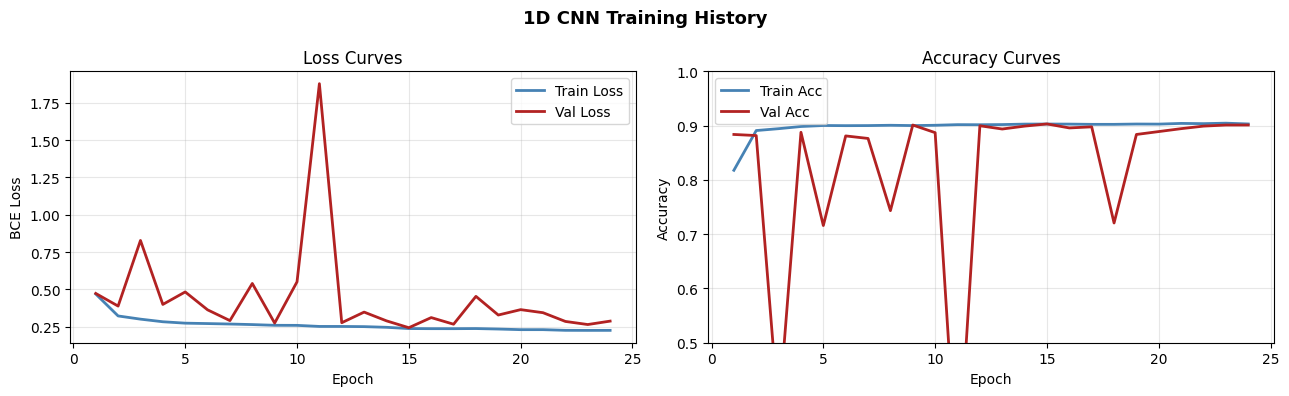

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epochs = range(1, len(history['train_loss']) + 1)

# Loss plot
ax1.plot(epochs, history['train_loss'], 'steelblue', lw=2, label='Train Loss')
ax1.plot(epochs, history['val_loss'],   'firebrick', lw=2, label='Val Loss')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE Loss")
ax1.set_title("Loss Curves")
ax1.legend()
ax1.grid(alpha=0.3)

# Accuracy plot
ax2.plot(epochs, history['train_acc'], 'steelblue', lw=2, label='Train Acc')
ax2.plot(epochs, history['val_acc'],   'firebrick', lw=2, label='Val Acc')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy Curves")
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_ylim(0.5, 1.0)

plt.suptitle("1D CNN Training History", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches='tight')
plt.show()


In [26]:
from sklearn.metrics import (roc_curve, auc, classification_report,confusion_matrix,
                             ConfusionMatrixDisplay,average_precision_score, precision_recall_curve)

def get_predictions(model,loader,device):
  all_prob = []
  all_label = []

  with torch.no_grad():
    for X_batch, y_batch in loader:
      X_batch = X_batch.to(device)
      prob = model(X_batch)
      all_prob.append(prob.cpu().numpy())
      all_label.append(y_batch.cpu().numpy())

  return np.concatenate(all_prob), np.concatenate(all_label)


prob_test, label_test = get_predictions(model,test_dl,device)
prob_train, label_train = get_predictions(model,train_dl,device)

preds_test = (prob_test > 0.5).astype(int)

fpr,tpr,thresholds = roc_curve(label_test,prob_test)
auc_score = auc(fpr,tpr)

print("AUC SCORE: ",auc_score)

AUC SCORE:  0.9172248513048971


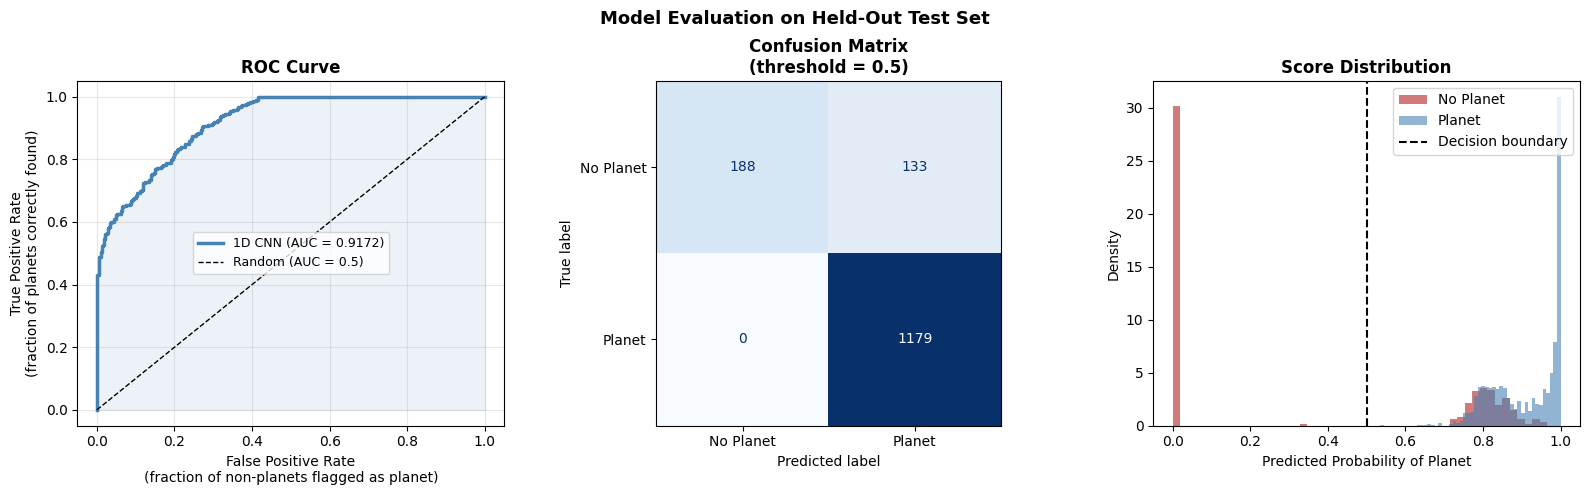


AUC Score: 0.9172

Classification Report:
              precision    recall  f1-score   support

   No Planet       1.00      0.59      0.74       321
      Planet       0.90      1.00      0.95      1179

    accuracy                           0.91      1500
   macro avg       0.95      0.79      0.84      1500
weighted avg       0.92      0.91      0.90      1500



In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ax = axes[0]
ax.plot(fpr, tpr, 'steelblue', lw=2.5,
        label=f'1D CNN (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')

ax.set_xlabel("False Positive Rate\n(fraction of non-planets flagged as planet)")
ax.set_ylabel("True Positive Rate\n(fraction of planets correctly found)")
ax.set_title("ROC Curve", fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)


ax = axes[1]
cm = confusion_matrix(label_test, preds_test)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Planet', 'Planet'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f"Confusion Matrix\n(threshold = 0.5)", fontweight='bold')

ax = axes[2]
ax.hist(prob_test[label_test == 0], bins=50, alpha=0.6,
        color='firebrick', label='No Planet', density=True)
ax.hist(prob_test[label_test == 1], bins=50, alpha=0.6,
        color='steelblue', label='Planet', density=True)
ax.axvline(0.5, color='black', ls='--', lw=1.5, label='Decision boundary')
ax.set_xlabel("Predicted Probability of Planet")
ax.set_ylabel("Density")
ax.set_title("Score Distribution", fontweight='bold')
ax.legend()

plt.suptitle("Model Evaluation on Held-Out Test Set", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("evaluation.png", dpi=120, bbox_inches='tight')
plt.show()

print(f"\nAUC Score: {auc_score:.4f}")
print("\nClassification Report:")
print(classification_report(label_test, preds_test,
                             target_names=['No Planet', 'Planet']))

# Testing on Real Kepler Data

/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(
/tmp/ipykernel_12654/2443018998.py:46: LightkurveDeprecationWarning: The PDCSAP_FLUX function is deprecated and may be removed in a future version.
  if hasattr(lc, 'PDCSAP_FLUX'):
/tmp/ipykernel_12654/2443018998.py:47: LightkurveDeprecationWarning: The PDCSAP_FLUX function is deprecated and may be removed in a future version.
  lc = lc.PDCSAP_FLUX
/tmp/ipykernel_12654/2443018998.py:46: LightkurveDeprecationWarning: The PDCSAP_FLUX function is deprecated and may be removed in a future version.
  if hasattr(lc, 'PDCSAP_FLUX'):
/tmp/ipykernel_12654/2443018998.py:47: LightkurveDeprecationWarning: The PDCSAP_FLUX function is deprecated and may be removed in a future version.
  lc = lc.PDCSAP_FLUX
/tmp/ipykernel_12654/2443018998.py:46: LightkurveDepr

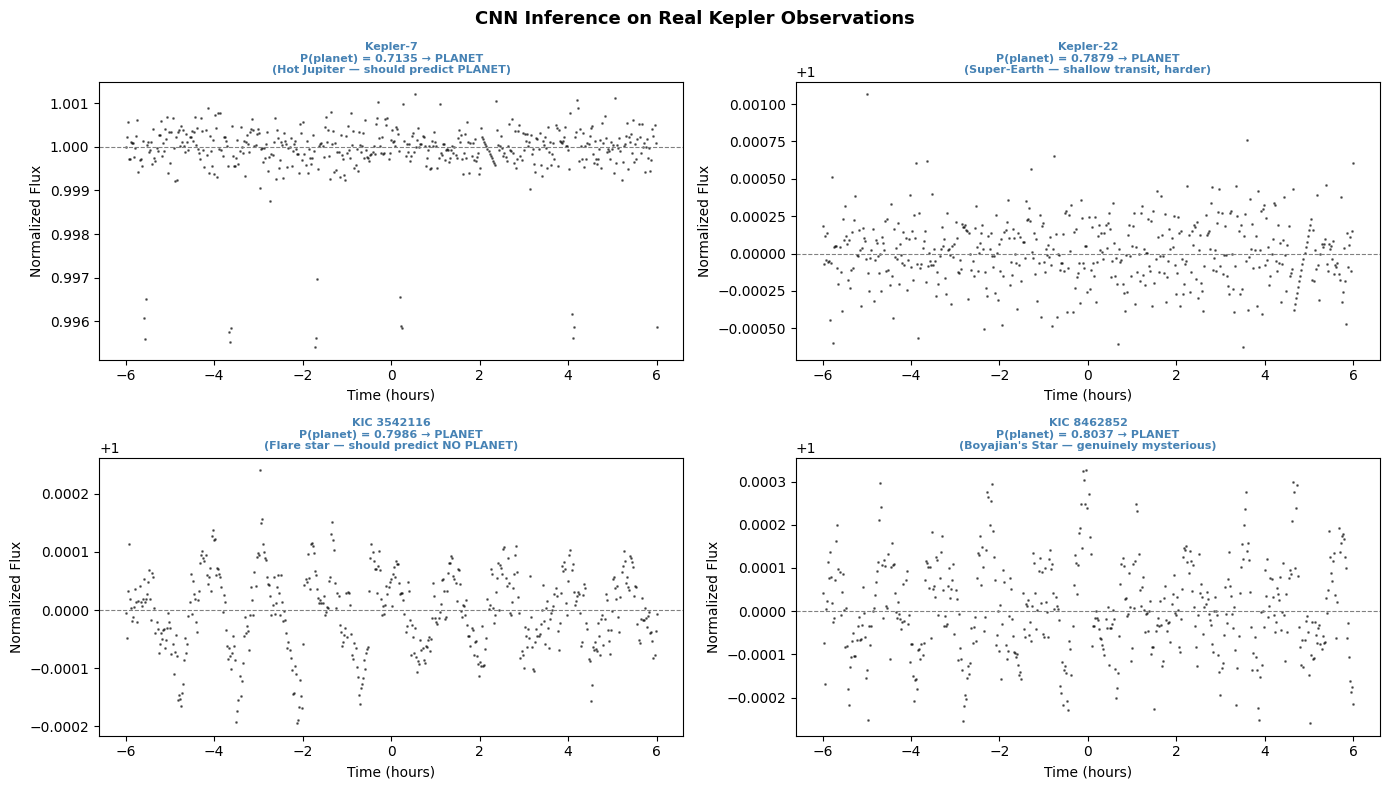

In [28]:
import lightkurve as lk

def get_real_lc(lc):
  lc_flat = lc.flatten(window_length=101)
  flux = lc_flat.flux.value
  ti = lc_flat.time.value

  mask = np.isfinite(flux)
  flux = flux[mask]
  ti = ti[mask]

  med = np.median(flux)
  std = np.std(flux)
  mask2 = np.abs(flux - med) < 5*std
  flux = flux[mask2]
  ti = ti[mask2]

  flux = flux / np.median(flux)

  t_new    = np.linspace(ti.min(), ti.max(), N_POINTS)
  flux_new = np.interp(t_new, ti, flux)

  return flux_new.astype(np.float32)

def pred_single(flux_array,model,device):
  model.eval()
  x = torch.tensor(flux_array[None,None,:],dtype = torch.float32).to(device)
  with torch.no_grad():
    prob = model(x).item()
  return prob

targets = [
    ('Kepler-7',    'Kepler', 'Hot Jupiter — should predict PLANET'),
    ('Kepler-22',   'Kepler', 'Super-Earth — shallow transit, harder'),
    ('KIC 3542116', 'Kepler', 'Flare star — should predict NO PLANET'),
    ('KIC 8462852', 'Kepler', "Boyajian's Star — genuinely mysterious"),
]

results = []
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for ax,(target,mission,desc) in zip(axes,targets):
  try:
    search = lk.search_lightcurve(target, mission=mission)
    lc = search[0].download()
    if hasattr(lc, 'PDCSAP_FLUX'):
      lc = lc.PDCSAP_FLUX
    lc = lc.normalize()
    flux_processed = get_real_lc(lc)
    prob = pred_single(flux_processed,model,device)
    prediction = "PLANET" if prob > 0.5 else "NO PLANET"
    results.append({
            'target':      target,
            'probability': prob,
            'prediction':  prediction,
            'description': desc
    })

    ax.plot(np.linspace(-T_HALF*24, T_HALF*24, N_POINTS),
                flux_processed, 'k.', ms=2, alpha=0.5)
    ax.axhline(1.0, color='gray', lw=0.8, ls='--')
    color = 'steelblue' if prob > 0.5 else 'firebrick'
    ax.set_title(
        f"{target}\n"
        f"P(planet) = {prob:.4f} → {prediction}\n"
        f"({desc})",
        fontsize=8, color=color, fontweight='bold'
    )
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Normalized Flux")

  except Exception as e:
    print(f"  Failed for {target}: {e}")
    ax.set_title(f"{target}\nDownload failed", color='gray')
    ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
            ha='center', va='center', color='gray')

plt.suptitle("CNN Inference on Real Kepler Observations",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("real_observations.png", dpi=120, bbox_inches='tight')
plt.show()

In [29]:
print("\n" + "="*65)
print(f"{'Target':<15} {'P(planet)':>10} {'Prediction':<15} {'Description'}")
print("="*65)
for r in results:
    print(f"{r['target']:<15} {r['probability']:>10.4f} "f"{r['prediction']:<15} {r['description']}")


Target           P(planet) Prediction      Description
Kepler-7            0.7135 PLANET          Hot Jupiter — should predict PLANET
Kepler-22           0.7879 PLANET          Super-Earth — shallow transit, harder
KIC 3542116         0.7986 PLANET          Flare star — should predict NO PLANET
KIC 8462852         0.8037 PLANET          Boyajian's Star — genuinely mysterious


In [30]:
def load_trained_model(path='models/transit_cnn.pt', device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    m = TransitCNN().to(device)
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval()
    return m, device


def run_inf(X_new, model=None, device=None, threshold=0.5):

    if model is None:
        model, device = load_trained_model()
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    X_processed = np.zeros((len(X_new), N_POINTS), dtype=np.float32)

    for i, lc in enumerate(X_new):
        med = np.median(lc)
        if med != 0:
            lc = lc / med
        if len(lc) != N_POINTS:
            t_old = np.linspace(0, 1, len(lc))
            t_new = np.linspace(0, 1, N_POINTS)
            lc    = np.interp(t_new, t_old, lc)

        X_processed[i] = lc.astype(np.float32)

    ds     = TensorDataset(torch.tensor(X_processed[:, None, :]))
    loader = DataLoader(ds, batch_size=256, shuffle=False)

    all_probs = []
    model.eval()

    with torch.no_grad():
        for (X_batch,) in loader:
            X_batch = X_batch.to(device)
            probs   = model(X_batch).cpu().numpy()
            all_probs.append(probs)

    probabilities = np.concatenate(all_probs)
    predictions   = (probabilities >= threshold).astype(int)
    return probabilities, predictions

print("Demo: inference on 10 withheld synthetic curves...")
demo_X, demo_y = [], []

for _ in range(5):
    s = sample_star()
    p = sample_planet(s)
    f = generate_transit(s, p)
    f_noisy, _ = generate_noisy_transit(f)
    demo_X.append(f_noisy)
    demo_y.append(1)

for gen in [gen_eclipsing_binary, gen_stellar_flare, gen_flat_no_transit,
            gen_eclipsing_binary, gen_stellar_flare]:
    f = gen()
    f_noisy, _ = generate_noisy_transit(f)
    demo_X.append(f_noisy)
    demo_y.append(0)

demo_X = np.array(demo_X)
demo_y = np.array(demo_y)

probs, preds = run_inf(demo_X, model, device)

print(f"\n{'#':>3} {'True':>10} {'Pred':>10} {'Prob':>8} {'OK?':>5}")
print("-" * 42)

for i, (true, pred, prob) in enumerate(zip(demo_y, preds, probs)):
    ok = 'yes' if pred == true else 'no'
    print(f"{i:>3} {'Planet' if true==1 else 'No Planet':>10} "
          f"{'Planet' if pred==1 else 'No Planet':>10} "
          f"{prob:>8.4f} {ok:>5}")

Demo: inference on 10 withheld synthetic curves...

  #       True       Pred     Prob   OK?
------------------------------------------
  0     Planet     Planet   0.7699   yes
  1     Planet     Planet   1.0000   yes
  2     Planet     Planet   0.9669   yes
  3     Planet     Planet   0.7895   yes
  4     Planet     Planet   0.7788   yes
  5  No Planet  No Planet   0.0000   yes
  6  No Planet  No Planet   0.0000   yes
  7  No Planet     Planet   0.7913    no
  8  No Planet  No Planet   0.0000   yes
  9  No Planet  No Planet   0.0000   yes
